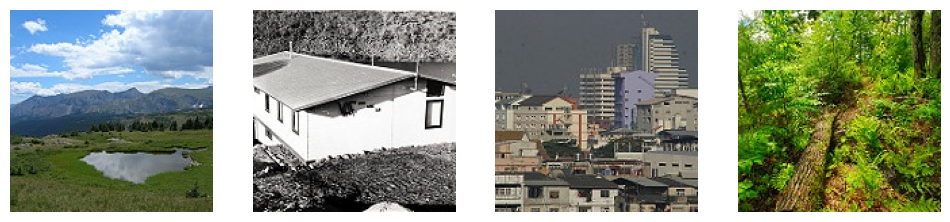

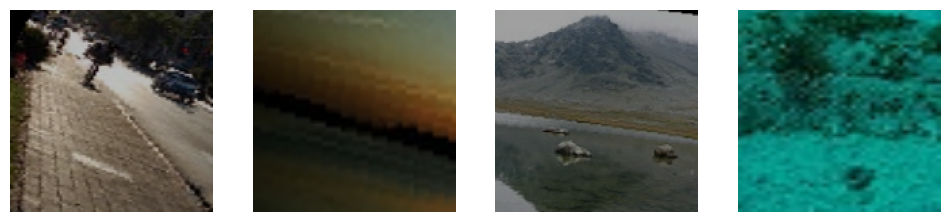

Época 1, Pérdida: 1.7750468121634588
Época 2, Pérdida: 1.7061269382635753
Época 3, Pérdida: 1.670866847038269
Época 4, Pérdida: 1.6271353198422327
Época 5, Pérdida: 1.5610074467129178
Época 6, Pérdida: 1.5617781463596556
Época 7, Pérdida: 1.5657531552844577
Época 8, Pérdida: 1.5054510864946578
Época 9, Pérdida: 1.4940895256068971
Época 10, Pérdida: 1.4640904151731067
Época 11, Pérdida: 1.5133284247583814
Época 12, Pérdida: 1.417860017882453
Época 13, Pérdida: 1.4736094507906172
Época 14, Pérdida: 1.4027890066305797
Época 15, Pérdida: 1.4385196665922801
Época 16, Pérdida: 1.432377427816391
Época 17, Pérdida: 1.3894049492147234
Época 18, Pérdida: 1.4485224104589887
Época 19, Pérdida: 1.406782552599907
Época 20, Pérdida: 1.3360792812373903
Época 21, Pérdida: 1.3651968555317984
Época 22, Pérdida: 1.3863145096434488
Época 23, Pérdida: 1.3648332787884607
Época 24, Pérdida: 1.3006404158141878
Época 25, Pérdida: 1.2553935961590872
Época 26, Pérdida: 1.2684412333700392
Época 27, Pérdida: 1.2586

In [13]:
# Importar las librerías necesarias
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Definir la ruta de las imágenes utilizando la ruta absoluta
data_dir = './images'  # Carpeta principal que contiene las subcarpetas con imágenes

# Crear una transformación simple para cargar las imágenes como tensores
transform = transforms.Compose([transforms.ToTensor()])

# Cargar las imágenes usando ImageFolder, especificando el num_workers
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=1)  # num_workers definido

# Visualizar algunas imágenes originales utilizando next(iter())
data_iter = iter(dataloader)
images, labels = next(data_iter)

# Mostrar las imágenes originales
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(images[i].permute(1, 2, 0))
    axes[i].axis('off')
plt.show()

# Aplicar augmentación de imágenes
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(150),
    transforms.ColorJitter(brightness=0.5),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor()
])

# Recargar el dataset con augmentación
augmented_dataset = datasets.ImageFolder(root=data_dir, transform=augment_transform)
augmented_dataloader = DataLoader(augmented_dataset, batch_size=4, shuffle=True, num_workers=1)  # num_workers definido

# Visualizar algunas imágenes augmentadas utilizando next(iter())
data_iter = iter(augmented_dataloader)
aug_images, labels = next(data_iter)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(aug_images[i].permute(1, 2, 0))
    axes[i].axis('off')
plt.show()

# Definir la red convolucional, calculando correctamente el tamaño para las capas fully connected
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        
        # Asegurarse de que las dimensiones después de las convoluciones son correctas
        # Para imágenes de 150x150, las convoluciones y maxpool resultarán en un tamaño de (32, 37, 37)
        self.fc1 = nn.Linear(32 * 37 * 37, 128)  # Actualizar con las dimensiones correctas
        self.fc2 = nn.Linear(128, len(dataset.classes))

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 37 * 37)  # Ajustar al tamaño correcto después de las capas convolucionales
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Crear una instancia del modelo
model = CNNModel()

# Definir el criterio de pérdida
criterion = nn.CrossEntropyLoss()

# Definir el optimizador con weight_decay
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=0.0003)

# Entrenar el modelo
epochs = 30
for epoch in range(epochs):
    running_loss = 0.0
    for inputs, labels in augmented_dataloader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)  # Aquí se utiliza criterion
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Época {epoch+1}, Pérdida: {running_loss/len(augmented_dataloader)}")

# Evaluación del modelo en imágenes no augmentadas
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in dataloader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Precisión del modelo: {100 * correct / total}%')
